In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from scipy.spatial.distance import jensenshannon

folder_path = "/content/drive/MyDrive/Colab Notebooks/MAWAR MERAH dan BIRU"
output_file = "/content/drive/MyDrive/Colab Notebooks/folder program/outputJS.xlsx"

# Get all image files
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png'))]

# List to store all data records
records = []

for file in image_files:
    img_path = os.path.join(folder_path, file)
    with Image.open(img_path) as img:
        # Split channels
        r, g, b = img.split()

        # Convert to numpy arrays
        r_data = np.array(r.getdata())
        g_data = np.array(g.getdata())
        b_data = np.array(b.getdata())

        # Histograms (256 bins for 0-255 values)
        r_counts, _ = np.histogram(r_data, bins=256, range=(0, 256))
        g_counts, _ = np.histogram(g_data, bins=256, range=(0, 256))
        b_counts, _ = np.histogram(b_data, bins=256, range=(0, 256))

        # Relative frequencies
        r_rel = r_counts / len(r_data)
        g_rel = g_counts / len(g_data)
        b_rel = b_counts / len(b_data)

        # Joint frequency (product of marginals – assumes independence)
        joint_freq = r_rel * g_rel * b_rel   # length 256

        # Store record
        records.append({
            "file": file,
            "red_counts": r_counts,
            "red_rel_freq": r_rel,
            "green_counts": g_counts,
            "green_rel_freq": g_rel,
            "blue_counts": b_counts,
            "blue_rel_freq": b_rel,
            "joint_freq": joint_freq
        })

# Create DataFrame from the list of records
df = pd.DataFrame(records)

# --------------------------------------------------------------
# JS divergence between the reference images and all others
# --------------------------------------------------------------
# Reference: "Red 1.jpg" – ensure the exact filename exists
ref_red = df[df['file'] == 'Red 1.jpg']
if not ref_red.empty:
    red1_joint = ref_red.iloc[0]['joint_freq']
    df['jsd_Red1'] = df['joint_freq'].apply(lambda x: jensenshannon(red1_joint, x))

# Reference: "Blue 1.jpg"
ref_blue = df[df['file'] == 'Blue 1.jpg']
if not ref_blue.empty:
    blue1_joint = ref_blue.iloc[0]['joint_freq']
    df['jsd_Blue1'] = df['joint_freq'].apply(lambda x: jensenshannon(blue1_joint, x))

# Save to Excel
df.to_excel(output_file, index=False)
print(f"Results saved to {output_file}")

Results saved to /content/drive/MyDrive/Colab Notebooks/folder program/outputJS.xlsx


In [ ]:
import os
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon


def kmeans(data, k, max_iterations=100):
    # Initialize centroids with first two joint frequencies
    centroids = np.vstack((data[0]['joint_freq'], data[1]['joint_freq']))

    for iteration in range(max_iterations):
        # Assign data points to nearest centroid
        cluster_assignments = [np.argmin([jensenshannon(point['joint_freq'], centroid) for centroid in centroids]) for point in data]

        # Update centroids
        for i in range(k):
            cluster_points = [data[j] for j in range(len(data)) if cluster_assignments[j] == i]
            if cluster_points:
                cluster_joint_freqs = [point['joint_freq'] for point in cluster_points]
                centroids[i] = np.mean(cluster_joint_freqs, axis=0)

    return cluster_assignments, centroids


folder_path = "/content/drive/MyDrive/Colab Notebooks/MAWAR MERAH dan BIRU" # replace with your folder path
output_file = "/content/drive/MyDrive/Colab Notebooks/folder program/outputJSKmeans.xlsx" # replace with your output file name

image_files = [f for f in os.listdir(folder_path) if f.endswith(".jpg") or f.endswith(".png")] # filter image files

data = []
for file in image_files:
    image = Image.open(os.path.join(folder_path, file)) # open the image
    r, g, b = image.split() # split the channels
    r_data = np.array(r.getdata()) # convert to numpy array for faster calculations
    g_data = np.array(g.getdata())
    b_data = np.array(b.getdata())
    r_counts, r_bins = np.histogram(r_data, bins=[0, 85,170, 255]) # calculate histogram for red channel
    g_counts, g_bins = np.histogram(g_data, bins=[0, 85,170, 255]) # calculate histogram for green channel
    b_counts, b_bins = np.histogram(b_data, bins=[0, 85,170, 255]) # calculate histogram for blue channel
    r_rel_freq = r_counts / len(r_data) # calculate relative frequency for red channel
    g_rel_freq = g_counts / len(g_data) # calculate relative frequency for green channel
    b_rel_freq = b_counts / len(b_data) # calculate relative frequency for blue channel
    joint_freq = r_rel_freq * g_rel_freq * b_rel_freq # calculate joint frequency
    data.append({'file': file, 'joint_freq': joint_freq})

# Run k-means clustering with k=2
cluster_assignments, centroids = kmeans(data, k=2)

# Output cluster assignments to a DataFrame and save to an Excel file
df = pd.DataFrame({'file': image_files, 'cluster_assignment': cluster_assignments})
df.to_excel(output_file)



/usr/local/lib/python3.12/dist-packages/scipy/spatial/distance.py:1378: RuntimeWarning: invalid value encountered in divide
  p = p / np.sum(p, axis=axis, keepdims=True)
/usr/local/lib/python3.12/dist-packages/scipy/spatial/distance.py:1379: RuntimeWarning: invalid value encountered in divide
  q = q / np.sum(q, axis=axis, keepdims=True)


✅ Excel tersimpan di: /content/drive/MyDrive/Colab Notebooks/folder program/outputJS.xlsx


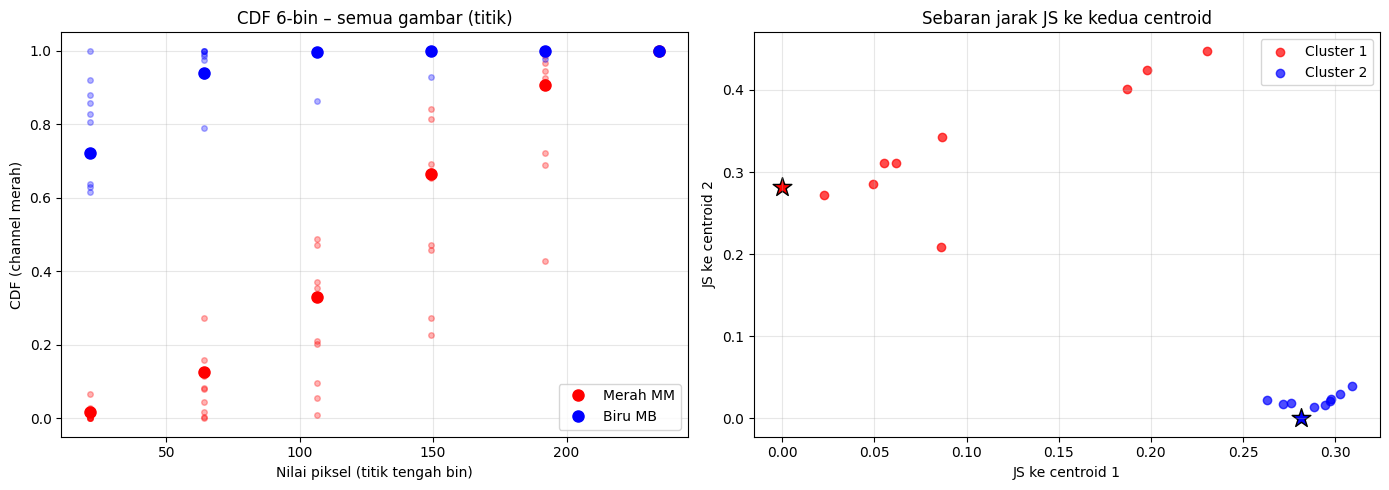

📊 Plot telah disimpan dan ditampilkan.


In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from scipy.spatial.distance import jensenshannon
import matplotlib.pyplot as plt

# ------------------------------
# Konfigurasi
# ------------------------------
folder_path = "/content/drive/MyDrive/Colab Notebooks/MAWAR MERAH dan BIRU"
output_file = "/content/drive/MyDrive/Colab Notebooks/folder program/outputJS.xlsx"

# Nama file centroid (pastikan ada di folder)
centroid1_file = "MM 1.jpg"
centroid2_file = "MB 1.jpg"

# Jumlah bin
N_BINS = 6

# ------------------------------
# Fungsi bantu: ekstrak CDF 6-bin dari channel merah
# ------------------------------
def get_red_cdf(image_path, bins=N_BINS):
    """Buka gambar, ambil channel merah, hitung histogram 6 bin, PDF, dan CDF."""
    with Image.open(image_path) as img:
        r = img.split()[0]          # channel merah
        r_data = np.array(r.getdata())
    # Histogram 6 bin (rentang 0-255)
    counts, edges = np.histogram(r_data, bins=bins, range=(0, 256))
    pdf = counts / len(r_data)
    cdf = np.cumsum(pdf)
    return counts, pdf, cdf, edges

# ------------------------------
# Baca semua file gambar
# ------------------------------
image_files = [f for f in os.listdir(folder_path)
               if f.lower().endswith(('.jpg', '.png'))]

# ------------------------------
# Kumpulkan data setiap gambar
# ------------------------------
records = []
for file in image_files:
    path = os.path.join(folder_path, file)
    counts, pdf, cdf, edges = get_red_cdf(path, bins=N_BINS)
    records.append({
        "file": file,
        "red_counts_6bin": counts,
        "red_pdf_6bin": pdf,
        "red_cdf_6bin": cdf,
        "bin_edges": edges
    })

df = pd.DataFrame(records)

# ------------------------------
# Hitung CDF centroid (MM1.jpg dan MB.jpg)
# ------------------------------
# Cari baris centroid
row_c1 = df[df['file'] == centroid1_file]
row_c2 = df[df['file'] == centroid2_file]

if row_c1.empty or row_c2.empty:
    raise FileNotFoundError(f"Centroid file {centroid1_file} atau {centroid2_file} tidak ditemukan!")

cdf_c1 = row_c1.iloc[0]['red_cdf_6bin']
cdf_c2 = row_c2.iloc[0]['red_cdf_6bin']
edges_c1 = row_c1.iloc[0]['bin_edges']   # sama untuk semua gambar

# ------------------------------
# Hitung JS divergence dan tentukan klaster
# ------------------------------
def js_div(cdf1, cdf2):
    """Jensen-Shannon distance antara dua CDF (array 1D)."""
    return jensenshannon(cdf1, cdf2)

df['js_to_centroid1'] = df['red_cdf_6bin'].apply(lambda cdf: js_div(cdf, cdf_c1))
df['js_to_centroid2'] = df['red_cdf_6bin'].apply(lambda cdf: js_div(cdf, cdf_c2))
df['cluster'] = (df['js_to_centroid1'] > df['js_to_centroid2']).map({True: 2, False: 1})

# ------------------------------
# Simpan ke Excel
# ------------------------------
df_excel = df.copy()
df_excel['red_counts_6bin'] = df_excel['red_counts_6bin'].apply(list)
df_excel['red_pdf_6bin'] = df_excel['red_pdf_6bin'].apply(list)
df_excel['red_cdf_6bin'] = df_excel['red_cdf_6bin'].apply(list)
df_excel['bin_edges'] = df_excel['bin_edges'].apply(list)

df_excel = df_excel[['file', 'red_counts_6bin', 'red_pdf_6bin', 'red_cdf_6bin',
                     'js_to_centroid1', 'js_to_centroid2', 'cluster']]
df_excel.to_excel(output_file, index=False)
print(f"✅ Excel tersimpan di: {output_file}")

# ------------------------------
# Visualisasi
# ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot kiri: CDF dengan titik (marker) ---
ax = axes[0]
# Titik tengah bin (actual bin centers)
bin_centers = (edges_c1[:-1] + edges_c1[1:]) / 2

# Plot semua gambar dengan titik transparan (warna sesuai klaster)
for _, row in df.iterrows():
    cdf = row['red_cdf_6bin']
    cluster = row['cluster']
    color = 'red' if cluster == 1 else 'blue'
    ax.plot(bin_centers, cdf, 'o', color=color, alpha=0.3, markersize=4)

# Plot centroid dengan marker besar dan label khusus
ax.plot(bin_centers, cdf_c1, 'o', color='red', markersize=8, label='Merah MM')
ax.plot(bin_centers, cdf_c2, 'o', color='blue', markersize=8, label='Biru MB')

ax.set_xlabel('Nilai piksel (titik tengah bin)')
ax.set_ylabel('CDF (channel merah)')
ax.set_title('CDF 6-bin – semua gambar (titik)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot kanan: Scatter jarak JS ke kedua centroid ---
ax = axes[1]
colors = {1: 'red', 2: 'blue'}
for cluster in [1, 2]:
    subset = df[df['cluster'] == cluster]
    ax.scatter(subset['js_to_centroid1'], subset['js_to_centroid2'],
               c=colors[cluster], label=f'Cluster {cluster}', alpha=0.7)
# Tandai centroid itu sendiri (jarak 0 ke dirinya sendiri)
ax.scatter(0, df.loc[row_c1.index[0], 'js_to_centroid2'], c='red', marker='*', s=200, edgecolor='black')
ax.scatter(df.loc[row_c2.index[0], 'js_to_centroid1'], 0, c='blue', marker='*', s=200, edgecolor='black')
ax.set_xlabel('JS ke centroid 1')
ax.set_ylabel('JS ke centroid 2')
ax.set_title('Sebaran jarak JS ke kedua centroid')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/folder program/clustering_plot.png', dpi=150)
plt.show()

print("📊 Plot telah disimpan dan ditampilkan.")

Memulai 30 kali pengulangan eksperimen K-Means...
Eksperimen selesai.
✅ Data eksperimen tersimpan di: /content/drive/MyDrive/Colab Notebooks/folder program/output_iterasi.xlsx


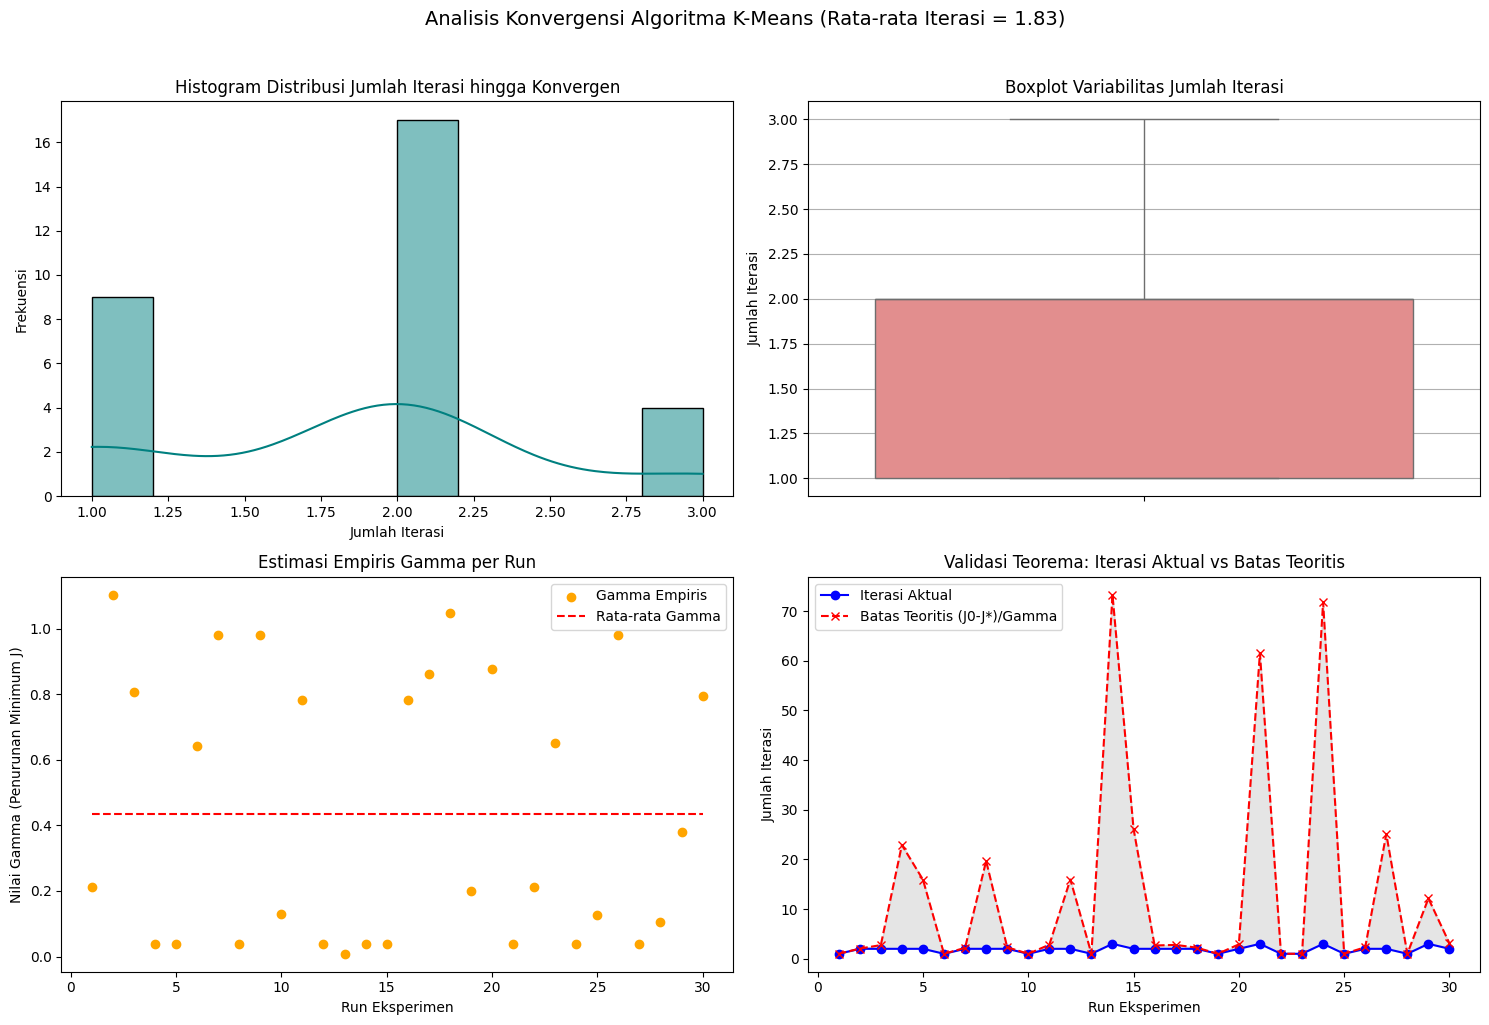

📊 Plot analisis konvergensi berhasil disimpan.


In [ ]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
from PIL import Image
from scipy.spatial.distance import jensenshannon
import matplotlib.pyplot as plt
import seaborn as sns
import random

# ==============================
# KONFIGURASI
# ==============================
folder_path = "/content/drive/MyDrive/Colab Notebooks/MAWAR MERAH dan BIRU"
output_file = "/content/drive/MyDrive/Colab Notebooks/folder program/output_iterasi.xlsx"
N_BINS = 6
N_CLUSTERS = 2
N_RUNS = 30          # Rekomendasi: minimal 10-30 kali pengulangan (syarat evaluasi)
MAX_ITER = 100       # Maksimum iterasi per run
TOLERANCE = 1e-6     # Toleransi konvergensi (berhenti jika perubahan fungsi objektif < 1e-6)

# ==============================
# FUNGSI BANTU
# ==============================
def get_red_cdf(image_path, bins=N_BINS):
    """Mengambil CDF channel merah dengan 6 bin."""
    with Image.open(image_path) as img:
        r = img.split()[0]
        r_data = np.array(r.getdata())
    counts, _ = np.histogram(r_data, bins=bins, range=(0, 256))
    pdf = counts / len(r_data)
    cdf = np.cumsum(pdf)
    return cdf

def pointwise_mean(cdfs_list):
    """Menghitung rata-rata pointwise (centroid CDF) dari list CDF."""
    if len(cdfs_list) == 0:
        return None
    return np.mean(cdfs_list, axis=0)

def calculate_js_div(cdf1, cdf2):
    """Menghitung Jensen-Shannon Distance (bukan KL) antara 2 CDF."""
    # Tambahkan epsilon kecil untuk menghindari nol absolut jika perlu,
    # tapi scipy jensenshannon menangani kasus nol dengan baik.
    return jensenshannon(cdf1, cdf2)

# ==============================
# EKSTRAKSI DATA & ITERASI K-MEANS
# ==============================
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png'))]
cdfs = []
file_names = []

for file in image_files:
    path = os.path.join(folder_path, file)
    cdf = get_red_cdf(path)
    cdfs.append(cdf)
    file_names.append(file)

cdfs = np.array(cdfs)
n_samples = len(cdfs)

def run_kmeans_once(cdfs, K=2, max_iter=100, tol=1e-6):
    """Menjalankan K-Means iteratif dengan JS Divergence dan pointwise centroid."""
    n = len(cdfs)

    # 1. Inisialisasi Acak: Pilih K indeks gambar berbeda sebagai centroid awal
    init_indices = random.sample(range(n), K)
    centroids = [cdfs[i] for i in init_indices]

    J_history = []      # Menyimpan nilai fungsi objektif tiap iterasi
    cluster_history = [] # Menyimpan partisi tiap iterasi

    for t in range(max_iter):
        # --- Langkah Assignment ---
        # Hitung matriks jarak JS ke setiap centroid
        dist_matrix = np.zeros((n, K))
        for i, cdf in enumerate(cdfs):
            for k, centroid in enumerate(centroids):
                dist_matrix[i, k] = calculate_js_div(cdf, centroid)

        # Tentukan klaster terdekat
        assignments = np.argmin(dist_matrix, axis=1)

        # Hitung fungsi objektif J (Total JS Divergence)
        J_t = np.sum(np.min(dist_matrix, axis=1))

        # --- Cek Konvergensi ---
        if len(J_history) > 0:
            delta_J = J_history[-1] - J_t  # Penurunan fungsi objektif
            if abs(delta_J) < tol or (len(cluster_history) > 0 and np.array_equal(cluster_history[-1], assignments)):
                J_history.append(J_t)
                cluster_history.append(assignments)
                break

        J_history.append(J_t)
        cluster_history.append(assignments)

        # --- Langkah Update Centroid (Pointwise Mean) ---
        new_centroids = []
        for k in range(K):
            cluster_members = cdfs[assignments == k]
            if len(cluster_members) == 0:
                # Jika ada klaster kosong, inisialisasi ulang centroid dengan data acak
                new_centroids.append(cdfs[random.randint(0, n-1)])
            else:
                new_centroids.append(pointwise_mean(cluster_members))

        centroids = new_centroids

    return J_history, len(J_history) - 1  # (J_history, jumlah_iterasi_efektif)

# ==============================
# JALANKAN EKSPERIMEN 30 KALI (N_RUNS)
# ==============================
all_results = []

print(f"Memulai {N_RUNS} kali pengulangan eksperimen K-Means...")

for run in range(N_RUNS):
    # Set seed untuk reproduksibilitas jika ingin, tapi opsional
    random.seed(run * 10 + 1)

    J_history, n_iter = run_kmeans_once(cdfs, K=N_CLUSTERS, max_iter=MAX_ITER, tol=TOLERANCE)

    # Hitung Estimasi Empiris Gamma
    # Definisi gamma = penurunan minimum fungsi objektif antar dua partisi berbeda
    # Kita ambil nilai minimum dari delta J
    deltas = [J_history[i] - J_history[i+1] for i in range(len(J_history)-1)]
    gamma_estimate = min(deltas) if deltas else 0.0

    # Hitung batas atas teoritis (T_th)
    J_0 = J_history[0]
    J_star = J_history[-1]
    if gamma_estimate > 0:
        T_theoretical = (J_0 - J_star) / gamma_estimate
    else:
        T_theoretical = n_iter  # Jika gamma 0, konvergen tidak pernah turun, gunakan iterasi aktual sebagai pembatas

    all_results.append({
        "run": run + 1,
        "iterations_actual": n_iter,
        "J_0": J_0,
        "J_star": J_star,
        "Gamma_empirical": gamma_estimate,
        "T_theoretical_bound": T_theoretical,
        "J_history": J_history
    })

print("Eksperimen selesai.")

# ==============================
# SIMPAN KE EXCEL & PLOT
# ==============================
df_summary = pd.DataFrame(all_results)
df_summary.drop(columns=['J_history'], inplace=True)
df_summary.to_excel(output_file, index=False)
print(f"✅ Data eksperimen tersimpan di: {output_file}")

# --- Visualisasi Histogram & Boxplot ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plt.subplots_adjust(hspace=0.4)

# 1. Histogram Jumlah Iterasi
sns.histplot(df_summary['iterations_actual'], bins=10, kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Histogram Distribusi Jumlah Iterasi hingga Konvergen', fontsize=12)
axes[0, 0].set_xlabel('Jumlah Iterasi')
axes[0, 0].set_ylabel('Frekuensi')

# 2. Boxplot Jumlah Iterasi
sns.boxplot(y=df_summary['iterations_actual'], ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Boxplot Variabilitas Jumlah Iterasi', fontsize=12)
axes[0, 1].set_ylabel('Jumlah Iterasi')
axes[0, 1].grid(True, axis='y')

# 3. Analisis Gamma vs Batas Teoritis
axes[1, 0].scatter(df_summary['run'], df_summary['Gamma_empirical'], color='orange', label='Gamma Empiris')
axes[1, 0].plot(df_summary['run'], [np.mean(df_summary['Gamma_empirical'])] * N_RUNS, 'r--', label='Rata-rata Gamma')
axes[1, 0].set_xlabel('Run Eksperimen')
axes[1, 0].set_ylabel('Nilai Gamma (Penurunan Minimum J)')
axes[1, 0].set_title('Estimasi Empiris Gamma per Run')
axes[1, 0].legend()

# 4. Jumlah Iterasi aktual vs Batas Teoritis T
axes[1, 1].plot(df_summary['run'], df_summary['iterations_actual'], 'b-o', label='Iterasi Aktual')
axes[1, 1].plot(df_summary['run'], df_summary['T_theoretical_bound'], 'r--x', label='Batas Teoritis (J0-J*)/Gamma')
axes[1, 1].fill_between(df_summary['run'], df_summary['iterations_actual'], df_summary['T_theoretical_bound'], color='gray', alpha=0.2)
axes[1, 1].set_xlabel('Run Eksperimen')
axes[1, 1].set_ylabel('Jumlah Iterasi')
axes[1, 1].set_title('Validasi Teorema: Iterasi Aktual vs Batas Teoritis')
axes[1, 1].legend()

plt.suptitle(f'Analisis Konvergensi Algoritma K-Means (Rata-rata Iterasi = {np.mean(df_summary["iterations_actual"]):.2f})', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/folder program/konvergensi_analysis.png', dpi=150)
plt.show()

print("📊 Plot analisis konvergensi berhasil disimpan.")

In [ ]:
# ==========================================================
# PERBAIKAN POIN NO. 9 (Eksperimen Waktu & Standar Deviasi pada CIFAR-10)
# ==========================================================
# - Menggunakan 30 kali pengulangan (multi-run) untuk mengukur variabilitas.
# - Mencatat: Total Waktu Latih, Waktu/Iterasi, Jumlah Iterasi, Memori Puncak.
# - Melaporkan hasil dalam format Rata-rata ± Standar Deviasi.
# - Inisialisasi centroid menggunakan gambar pertama dari 10 kelas CIFAR-10.
# ==========================================================

import os
import numpy as np
import pandas as pd
import time
import tracemalloc
import matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon

# Instal & Import torchvision untuk memuat CIFAR-10 (Standard di Colab)
try:
    from torchvision import datasets, transforms
except ImportError:
    !pip install torchvision
    from torchvision import datasets, transforms

# ==============================
# KONFIGURASI
# ==============================
N_BINS = 10            # Jumlah bin per kanal warna (Total fitur = 3*10 = 30)
N_RUNS = 30            # Jumlah pengulangan eksperimen (sesuai rekomendasi dosen)
MAX_ITER = 50          # Maksimum iterasi K-Means
TOLERANCE = 1e-6       # Toleransi konvergensi
OUTPUT_EXCEL = "/content/drive/MyDrive/Colab Notebooks/folder program/output_cifar10_iterasi.xlsx"

# ==============================
# EKSTRAKSI FITUR (ECDF 10-bin per Kanal RGB)
# ==============================
def get_image_features(img_tensor, bins=N_BINS):
    """
    Mengambil fitur CDF per kanal warna dari CIFAR-10 image tensor.
    """
    # Konversi tensor (3,32,32) [0-1] ke numpy array (32,32,3) [0-255]
    img_np = (img_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    features = []
    for i in range(3):  # R, G, B
        channel_data = img_np[:, :, i].flatten()
        counts, _ = np.histogram(channel_data, bins=bins, range=(0, 256))
        pdf = counts / len(channel_data)
        cdf = np.cumsum(pdf)
        features.extend(cdf)
    return np.array(features)

# ==============================
# ALGORITMA K-MEANS BERBASIS JS DIVERGENCE
# ==============================
def run_kmeans_once(features_list, init_centroids, K=10, max_iter=50, tol=1e-6):
    """
    Menjalankan K-Means sekali dengan inisialisasi centroid tetap.
    Mengembalikan: jumlah_iterasi, waktu_per_iterasi
    """
    n_samples = len(features_list)
    centroids = init_centroids.copy()
    assignments = np.zeros(n_samples, dtype=int)
    iter_times = []

    for t in range(max_iter):
        start_iter = time.perf_counter()

        # --- 1. Assignment Step ---
        dist_matrix = np.zeros((n_samples, K))
        for i, f in enumerate(features_list):
            for k, c in enumerate(centroids):
                dist_matrix[i, k] = jensenshannon(f, c)

        new_assignments = np.argmin(dist_matrix, axis=1)

        # --- 2. Cek Konvergensi ---
        if t > 0 and np.array_equal(assignments, new_assignments):
            iter_time = time.perf_counter() - start_iter
            iter_times.append(iter_time)
            break

        assignments = new_assignments

        # --- 3. Update Step (Pointwise Mean) ---
        new_centroids = []
        for k in range(K):
            cluster_members = features_list[assignments == k]
            if len(cluster_members) > 0:
                new_centroids.append(np.mean(cluster_members, axis=0))
            else:
                new_centroids.append(init_centroids[k])  # Jika cluster kosong, pertahankan centroid awal

        centroids = np.array(new_centroids)

        iter_time = time.perf_counter() - start_iter
        iter_times.append(iter_time)

    return len(iter_times), np.mean(iter_times)

# ==============================
# PERSIAPAN DATA CIFAR-10
# ==============================
print("📥 Mendownload dataset CIFAR-10...")
transform = transforms.ToTensor()
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

print("🔍 Mengekstraksi fitur CDF dari 50.000 gambar...")
cdfs = []
for i in range(len(train_dataset)):
    img_tensor, _ = train_dataset[i]
    cdfs.append(get_image_features(img_tensor, bins=N_BINS))
cdfs = np.array(cdfs)

# Menentukan centroid awal (gambar pertama dari masing-masing 10 kelas)
# Dataset CIFAR-10: 0=Aircraft, 1=Automobile, 2=Bird, ..., 9=Truck
initial_centroid_indices = [0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000]
initial_centroids = cdfs[initial_centroid_indices]

print(f"✅ Dataset siap. Total Data: {len(cdfs)}, Dimensi Fitur: {cdfs.shape[1]}")

# ==============================
# EKSPERIMEN 30 KALI PENGULANGAN
# ==============================
results = {
    "run": [],
    "total_time": [],
    "n_iter": [],
    "avg_time_per_iter": [],
    "memory_peak_mb": []
}

print(f"🚀 Memulai {N_RUNS} kali pengulangan eksperimen K-Means pada CIFAR-10...")

for run in range(N_RUNS):
    # Reset memory tracker setiap run
    tracemalloc.start()
    start_total = time.perf_counter()

    # Jalankan K-Means
    n_iter, time_per_iter = run_kmeans_once(cdfs, initial_centroids, K=10, max_iter=MAX_ITER, tol=TOLERANCE)

    # Catat waktu total dan memori
    total_time = time.perf_counter() - start_total
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    # Simpan data
    results["run"].append(run + 1)
    results["total_time"].append(total_time)
    results["n_iter"].append(n_iter)
    results["avg_time_per_iter"].append(time_per_iter)
    results["memory_peak_mb"].append(peak / (1024 * 1024)) # Convert byte ke MB

    if (run + 1) % 5 == 0:
        print(f"   Selesai run ke-{run+1}/{N_RUNS}...")

# ==============================
# ANALISIS STATISTIK & OUTPUT
# ==============================
df_results = pd.DataFrame(results)
df_results.to_excel(OUTPUT_EXCEL, index=False)
print(f"\n✅ Data 30 pengulangan tersimpan di: {OUTPUT_EXCEL}")

# Hitung Mean dan Standar Deviasi
mean_total = np.mean(results["total_time"])
std_total = np.std(results["total_time"])

mean_iter = np.mean(results["n_iter"])
std_iter = np.std(results["n_iter"])

mean_time_iter = np.mean(results["avg_time_per_iter"])
std_time_iter = np.std(results["avg_time_per_iter"])

mean_mem = np.mean(results["memory_peak_mb"])
std_mem = np.std(results["memory_peak_mb"])

# ==============================
# FORMAT NARASI UNTUK DISERTASI (Sesuai Tabel 13)
# ==============================
print("\n" + "="*70)
print("📊 RINGKASAN HASIL EKSPERIMEN WAKTU & MEMORI (CIFAR-10, 30 ULANGAN)")
print("="*70)
print(f"Metode           : K-Means Berbasis Distribusi (CDF per kanal RGB, 10 bin)")
print(f"Jumlah Data      : 50.000 Gambar CIFAR-10")
print(f"Jumlah Ulangan   : {N_RUNS} Kali")
print("-" * 70)
print(f"Rata-rata Waktu Latih (Total)      : {mean_total:.4f} ± {std_total:.4f} detik")
print(f"Rata-rata Waktu per Iterasi       : {mean_time_iter:.4f} ± {std_time_iter:.4f} detik")
print(f"Rata-rata Jumlah Iterasi          : {mean_iter:.2f} ± {std_iter:.2f} iterasi")
print(f"Rata-rata Memori Puncak           : {mean_mem:.2f} ± {std_mem:.2f} MB")
print("="*70)

# ==============================
# PLOT DISTRIBUSI WAKTU DAN ITERASI (Untuk Dokumen)
# ==============================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.3)

# 1. Histogram Waktu Total
axes[0,0].hist(results["total_time"], bins=10, color='teal', edgecolor='black')
axes[0,0].set_xlabel('Waktu (detik)')
axes[0,0].set_ylabel('Frekuensi')
axes[0,0].set_title('Distribusi Waktu Latih Total')

# 2. Boxplot Waktu Total
axes[0,1].boxplot(results["total_time"], vert=True, patch_artist=True)
axes[0,1].set_ylabel('Waktu (detik)')
axes[0,1].set_title('Boxplot Variabilitas Waktu Latih')

# 3. Histogram Jumlah Iterasi
axes[1,0].hist(results["n_iter"], bins=10, color='lightcoral', edgecolor='black')
axes[1,0].set_xlabel('Jumlah Iterasi')
axes[1,0].set_ylabel('Frekuensi')
axes[1,0].set_title('Distribusi Jumlah Iterasi')

# 4. Scatter Waktu vs Iterasi (Menunjukkan korelasi)
axes[1,1].scatter(results["n_iter"], results["total_time"], alpha=0.7, color='blue')
axes[1,1].set_xlabel('Jumlah Iterasi')
axes[1,1].set_ylabel('Waktu Latih (detik)')
axes[1,1].set_title('Korelasi Iterasi vs Waktu Latih')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle(f'Eksperimen Waktu Komputasi CIFAR-10 (Rata-rata Waktu = {mean_total:.3f} ± {std_total:.3f} detik)', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/folder program/cifar10_time_analysis.png', dpi=150)
plt.show()

print("📊 Plot analisis waktu telah disimpan.")

📥 Mendownload dataset CIFAR-10...
🔍 Mengekstraksi fitur CDF dari 50.000 gambar...
✅ Dataset siap. Total Data: 50000, Dimensi Fitur: 30
🚀 Memulai 30 kali pengulangan eksperimen K-Means pada CIFAR-10...
   Selesai run ke-5/30...


KeyboardInterrupt: 